# Iris- AdaNet

### Importar Bibliotecas

In [8]:
import tensorflow as tf
import adanet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Carregar Dados

In [9]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Análise Exploratória

In [10]:
print("Dimensão:", df.shape)
print("\nClasses:")
print(df["target"].value_counts())
print("\nResumo:")
df.describe()

Dimensão: (150, 5)

Classes:
2    50
1    50
0    50
Name: target, dtype: int64

Resumo:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Distribuição das Classes

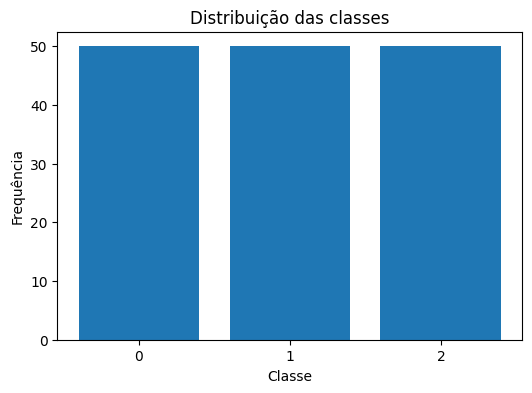

In [11]:
class_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.show()

A distribuição das classes no dataset revela um equilíbrio perfeito entre as três espécies (setosa, versicolor e virginica), o que elimina enviesamentos na aprendizagem e favorece uma avaliação mais justa do desempenho dos modelos.

### Distribuição das Variáveis

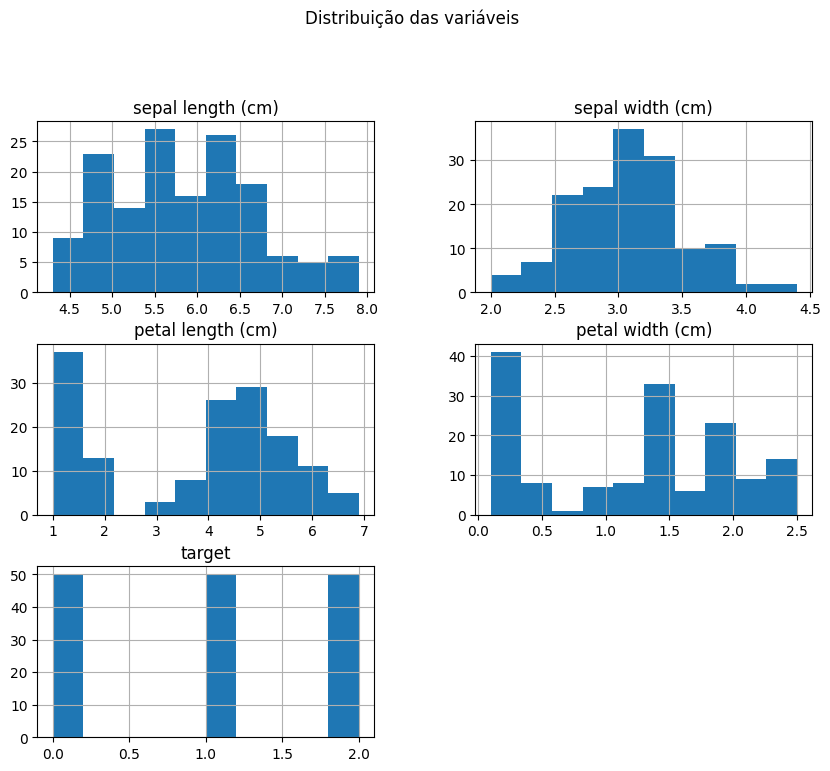

In [12]:
df.hist(figsize=(10, 8))
plt.suptitle("Distribuição das variáveis", y=1.02)
plt.show()

A distribuição das variáveis evidencia padrões distintos, destacando-se as variáveis petal_length e petal_width pela sua maior capacidade de separação entre classes, ao contrário das variáveis sepal, que apresentam maior sobreposição e menor poder discriminativo

### Relação entre Variáveis

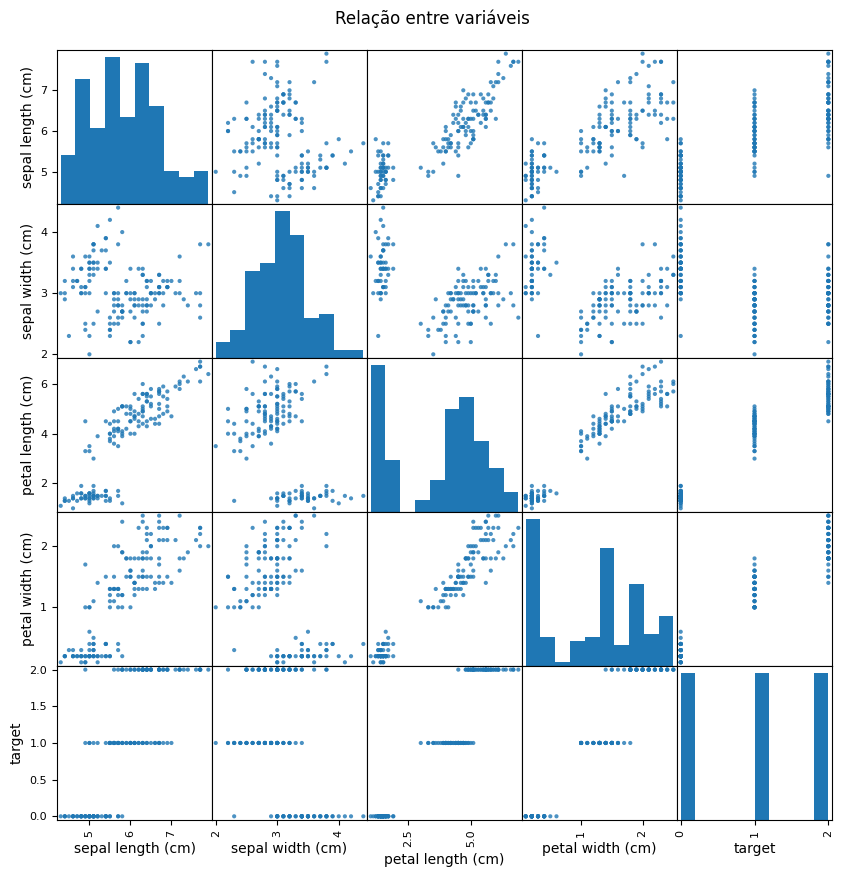

In [13]:
pd.plotting.scatter_matrix(
    df,
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.8
)

plt.suptitle("Relação entre variáveis", y=0.92)
plt.show()

A análise da relação entre variáveis evidencia uma clara separação entre as espécies, sobretudo nas variáveis petal_length e petal_width, onde os grupos se distinguem quase sem sobreposição, ao contrário das variáveis sepal, que apresentam maior dispersão e interseção entre classes

### Matriz de Correlação

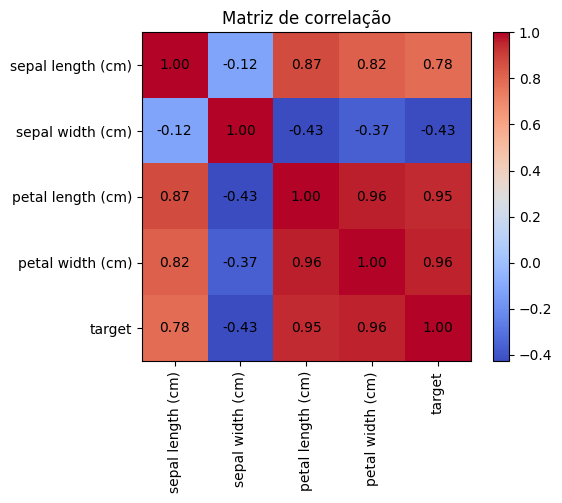

In [14]:
corr = df.corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlação")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

A matriz de correlação evidencia uma forte relação positiva entre petal_length e petal_width, indicando elevada redundância de informação, enquanto sepal_width apresenta correlações fracas ou negativas com as restantes variáveis, revelando menor relevância para a distinção entre classes.

## Conclusão da análise exploratória

- O dataset não apresenta valores em falta.
- As classes estão perfeitamente equilibradas.
- As variáveis petal length e petal width mostram maior capacidade de separação entre classes.
- As variáveis associadas às sépalas apresentam maior sobreposição e menor poder discriminativo.
- Existe forte correlação entre petal length e petal width.
- O problema apresenta baixa complexidade e elevada separabilidade.

Estas características ajudam a explicar o elevado desempenho dos modelos aplicados ao dataset Iris, incluindo o AdaNet.


### Preparar Dados

In [15]:
X = df.drop("target", axis=1).values.astype(np.float32)
y = df["target"].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Input Functions

In [16]:
train_input_fn = tf.compat.v1.estimator.inputs.numpy_input_fn(      # criar funções de entrada
    x={"features": X_train},
    y=y_train,
    batch_size=16,
    num_epochs=None,
    shuffle=True
)

test_input_fn = tf.compat.v1.estimator.inputs.numpy_input_fn(
    x={"features": X_test},
    y=y_test,
    batch_size=16,
    num_epochs=1,
    shuffle=False
)

### Feature columns e head

In [17]:
feature_columns = [
    tf.feature_column.numeric_column("features", shape=(4,))
]

head = tf.estimator.MultiClassHead(n_classes=3)        

### Candidate Pool

In [16]:
def candidate_pool(config):
    return {
        "linear": tf.estimator.LinearEstimator(
            head=head,
            feature_columns=feature_columns,
            config=config
        ),
        "dnn": tf.estimator.DNNEstimator(
            head=head,
            feature_columns=feature_columns,
            hidden_units=[16, 8],
            config=config
        ),
    }   #aqui definimos modelos candidatos

### Criar e Treinar AdaNet

In [32]:
adanet_estimator = adanet.AutoEnsembleEstimator(
    head=head,
    candidate_pool=candidate_pool,
    max_iteration_steps=50
)

adanet_estimator.train(
    input_fn=train_input_fn,
    steps=200
)   #AutoEnsembleEstimator, coloca nos modelos do candidate_pool e tenta construir um ensemble adaptativo, ou seja, um modelo final baseado na combinação progressiva desses candidatos.

INFO:tensorflow:Using default config.


INFO:tensorflow:Using default config.


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpclph216z', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpclph216z', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpclph216z', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


...

INFO:tensorflow:Saving checkpoints for 200 into C:\Users\anagil\AppData\Local\Temp\tmpclph216z\model.ckpt.


INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 200...


INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 200...


INFO:tensorflow:Loss for final step: 0.41134495.


INFO:tensorflow:Loss for final step: 0.41134495.


### Treinar os 2 Modelos Base

In [33]:
# Modelo linear
linear_estimator = tf.estimator.LinearEstimator(
    head=head,
    feature_columns=feature_columns
)

linear_estimator.train(input_fn=train_input_fn, steps=200)

# Modelo DNN
dnn_estimator = tf.estimator.DNNEstimator(
    head=head,
    feature_columns=feature_columns,
    hidden_units=[16, 8]
)

dnn_estimator.train(input_fn=train_input_fn, steps=200)

INFO:tensorflow:Using default config.


INFO:tensorflow:Using default config.


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpxzkviqii', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpxzkviqii', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


INFO:tensorflow:Calling model_fn.


...

INFO:tensorflow:Saving checkpoints for 200 into C:\Users\anagil\AppData\Local\Temp\tmpzicjr3m8\model.ckpt.


INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 200...


INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 200...


INFO:tensorflow:Loss for final step: 1.2633061.


INFO:tensorflow:Loss for final step: 1.2633061.


### Previsões dos 3 Modelos

In [34]:
# Previsões do modelo linear
linear_preds = list(linear_estimator.predict(input_fn=test_input_fn))
linear_classes = np.array([p["class_ids"][0] for p in linear_preds])

# Previsões do modelo DNN
dnn_preds = list(dnn_estimator.predict(input_fn=test_input_fn))
dnn_classes = np.array([p["class_ids"][0] for p in dnn_preds])

# Previsões do AdaNet
adanet_preds = list(adanet_estimator.predict(input_fn=test_input_fn))
adanet_classes = np.array([p["class_ids"][0] for p in adanet_preds])

INFO:tensorflow:Calling model_fn.


INFO:tensorflow:Calling model_fn.


INFO:tensorflow:Done calling model_fn.


INFO:tensorflow:Done calling model_fn.


INFO:tensorflow:Graph was finalized.


...

INFO:tensorflow:Restoring parameters from C:\Users\anagil\AppData\Local\Temp\tmpclph216z\model.ckpt-200


INFO:tensorflow:Running local_init_op.


INFO:tensorflow:Running local_init_op.


INFO:tensorflow:Done running local_init_op.


INFO:tensorflow:Done running local_init_op.


### Métricas dos 3 Modelos

In [35]:
linear_f1 = f1_score(y_test, linear_classes, average="weighted")
dnn_f1 = f1_score(y_test, dnn_classes, average="weighted")
adanet_f1 = f1_score(y_test, adanet_classes, average="weighted")

linear_acc = (linear_classes == y_test).mean()
dnn_acc = (dnn_classes == y_test).mean()
adanet_acc = (adanet_classes == y_test).mean()

df_modelos = pd.DataFrame({
    "Modelo": ["LinearEstimator", "DNNEstimator", "AdaNet"],
    "Accuracy": [linear_acc, dnn_acc, adanet_acc],
    "F1_score": [linear_f1, dnn_f1, adanet_f1]
})

df_modelos = df_modelos.sort_values(by="F1_score", ascending=False)
print(df_modelos)

            Modelo  Accuracy  F1_score
0  LinearEstimator  0.866667  0.861111
2           AdaNet  0.866667  0.861111
1     DNNEstimator  0.333333  0.166667


### Gráfico dos 3 Modelos

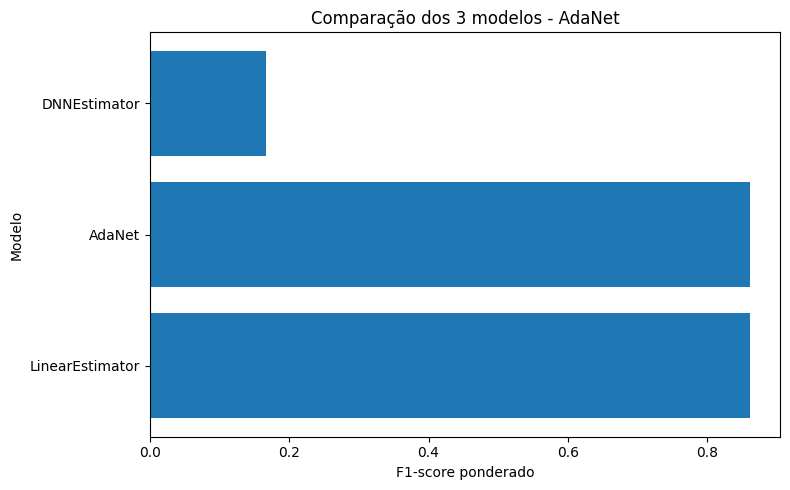

In [36]:
plt.figure(figsize=(8, 5))
plt.barh(df_modelos["Modelo"], df_modelos["F1_score"])
plt.xlabel("F1-score ponderado")
plt.ylabel("Modelo")
plt.title("Comparação dos 3 modelos - AdaNet")
plt.tight_layout()
plt.show()

O AdaNet e o LinearEstimator aprsentam desempenhos praticamente idênticos e elevados, indicando que a complexidade adicional do ensemble não trouxe gnhos relevantes neste porblema. Já o DNNEstimator teve um desempenho significativamente inferior, sugerindo que a maior complexidade do modelo não se traduz necessariamente em melhor desempenho num dataset simples como o Iris.

### Análise Automática dos 3 Modelos

In [37]:
print("=== Análise automática dos 3 modelos ===\n")

for _, row in df_modelos.iterrows():
    nome = row["Modelo"]
    acc = row["Accuracy"]
    f1 = row["F1_score"]
    
    print(f"Modelo: {nome}")
    print(f"- Accuracy: {acc:.4f}")
    print(f"- F1-score ponderado: {f1:.4f}")
    
    if nome == "LinearEstimator":
        print("- Trata-se de um modelo linear, mais simples e mais fácil de interpretar.")
    elif nome == "DNNEstimator":
        print("- Trata-se de uma rede neuronal, com maior capacidade para captar relações não lineares.")
    elif nome == "AdaNet":
        print("- Trata-se de um ensemble adaptativo, construído a partir dos modelos base.")
    
    if f1 > 0.95:
        print("- O desempenho é muito elevado, indicando que o dataset é facilmente separável.")
    elif f1 > 0.85:
        print("- O desempenho é bom, mas ainda com alguma margem para melhoria.")
    else:
        print("- O desempenho é moderado.")
    
    print("-" * 70)

=== Análise automática dos 3 modelos ===

Modelo: LinearEstimator
- Accuracy: 0.8667
- F1-score ponderado: 0.8611
- Trata-se de um modelo linear, mais simples e mais fácil de interpretar.
- O desempenho é bom, mas ainda com alguma margem para melhoria.
----------------------------------------------------------------------
Modelo: AdaNet
- Accuracy: 0.8667
- F1-score ponderado: 0.8611
- Trata-se de um ensemble adaptativo, construído a partir dos modelos base.
- O desempenho é bom, mas ainda com alguma margem para melhoria.
----------------------------------------------------------------------
Modelo: DNNEstimator
- Accuracy: 0.3333
- F1-score ponderado: 0.1667
- Trata-se de uma rede neuronal, com maior capacidade para captar relações não lineares.
- O desempenho é moderado.
----------------------------------------------------------------------


### Melhor Modelo

In [38]:
best_model_name = df_modelos.iloc[0]["Modelo"]
print("Melhor modelo:", best_model_name)

Melhor modelo: LinearEstimator


### Selecionar Previsões do Melhor Modelo

In [39]:
if best_model_name == "LinearEstimator":
    best_pred = linear_classes
elif best_model_name == "DNNEstimator":
    best_pred = dnn_classes
else:
    best_pred = adanet_classes

### Avaliação do Melhor Modelo

In [42]:
best_f1 = f1_score(y_test, best_pred, average="weighted")

print("=== Avaliação do melhor modelo ===")
print("F1-score ponderado:", best_f1)

print("\nRelatório de classificação:")
print(classification_report(y_test, best_pred, target_names=iris.target_names))

=== Avaliação do melhor modelo ===
F1-score ponderado: 0.861111111111111

Relatório de classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.71      1.00      0.83        10
   virginica       1.00      0.60      0.75        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.86        30
weighted avg       0.90      0.87      0.86        30



### Matriz de Confusão

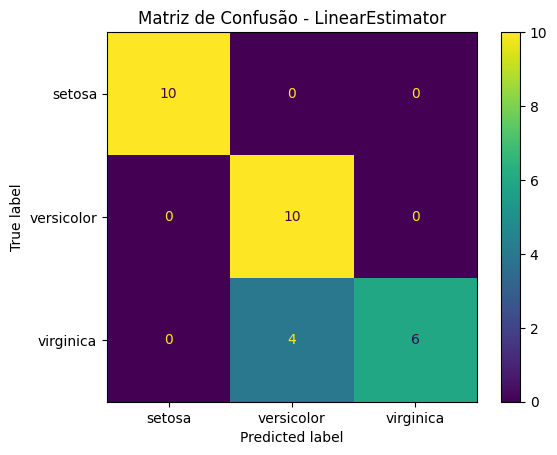

In [43]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title(f"Matriz de Confusão - {best_model_name}")
plt.show()

### AdaNet com Config em Ficheiro

In [18]:
import json

with open("config_adanet.json") as f:
    config = json.load(f)

print(config)

{'linear': {'usar': True}, 'dnn': {'usar': True, 'hidden_units': [16, 8]}, 'max_iteration_steps': 50, 'train_steps': 200}


In [19]:
# candidate pool a partir do ficheiro
def candidate_pool(config_estimator):
    candidatos = {}

    if config["linear"]["usar"]:
        candidatos["linear"] = tf.estimator.LinearEstimator(
            head=head,
            feature_columns=feature_columns,
            config=config_estimator
        )

    if config["dnn"]["usar"]:
        candidatos["dnn"] = tf.estimator.DNNEstimator(
            head=head,
            feature_columns=feature_columns,
            hidden_units=config["dnn"]["hidden_units"],
            config=config_estimator
        )

    return candidatos

In [20]:
# criar AdaNet com ficheiro
adanet_estimator = adanet.AutoEnsembleEstimator(
    head=head,
    candidate_pool=candidate_pool,
    max_iteration_steps=config["max_iteration_steps"]
)

INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpylgizc7m', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


In [24]:
# AdaNet com configuração externa em ficheiro

import json
import numpy as np
from sklearn.metrics import f1_score

# Ler ficheiro JSON
with open("config_adanet.json") as f:
    config_file = json.load(f)

print("Configuração carregada:")
print(config_file)

# Definir feature columns e head
feature_columns = [
    tf.feature_column.numeric_column("features", shape=(4,))
]

head = tf.estimator.MultiClassHead(n_classes=3)

# Candidate pool: tem de aceitar o argumento chamado "config"
def candidate_pool(config):
    candidatos = {}

    if config_file["linear"]["usar"]:
        candidatos["linear"] = tf.estimator.LinearEstimator(
            head=head,
            feature_columns=feature_columns,
            config=config
        )

    if config_file["dnn"]["usar"]:
        candidatos["dnn"] = tf.estimator.DNNEstimator(
            head=head,
            feature_columns=feature_columns,
            hidden_units=config_file["dnn"]["hidden_units"],
            config=config
        )

    return candidatos

# Criar AdaNet
adanet_estimator = adanet.AutoEnsembleEstimator(
    head=head,
    candidate_pool=candidate_pool,
    max_iteration_steps=config_file["max_iteration_steps"]
)

# Treinar
adanet_estimator.train(
    input_fn=train_input_fn,
    steps=config_file["train_steps"]
)

# Previsões
preds = list(adanet_estimator.predict(input_fn=test_input_fn))
y_pred = np.array([p["class_ids"][0] for p in preds])

# F1-score
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n=== Resultado AdaNet com Config em Ficheiro ===")
print("F1-score:", f1)

Configuração carregada:
{'linear': {'usar': True}, 'dnn': {'usar': True, 'hidden_units': [16, 8]}, 'max_iteration_steps': 50, 'train_steps': 200}
INFO:tensorflow:Using default config.


INFO:tensorflow:Using default config.


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpnsdl6nm9', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpnsdl6nm9', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\anagil\\AppData\\Local\\Temp\\tmpnsdl6nm9', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


...

INFO:tensorflow:Running local_init_op.


INFO:tensorflow:Running local_init_op.


INFO:tensorflow:Done running local_init_op.


INFO:tensorflow:Done running local_init_op.



=== Resultado AdaNet com Config em Ficheiro ===
F1-score: 0.6825396825396826


o AdaNet, o ficheiro de configuração foi utilizado para controlar os modelos candidatos e os principais parâmetros de treino. Contudo, a leitura desse ficheiro não é suportada nativamente pela biblioteca, exigindo código intermédio que traduz a configuração externa em objetos TensorFlow. Assim, o ficheiro condiciona a escolha dos modelos, mas a sua implementação continua dependente da definição manual da função candidate_pool.

# AdaNet

No AdaNet, a comparação foi feita entre os dois modelos base definidos no candidate_pool
(LinearEstimator e DNNEstimator) e o modelo final AdaNet, que funciona como um ensemble adaptativo.

A análise mostrou qual dos três apresentou melhor desempenho no conjunto de teste.
No entanto, tratando-se do dataset Iris, as diferenças entre modelos tendem a ser reduzidas,
o que confirma que a maior complexidade do ensemble nem sempre se traduz em ganhos práticos relevantes.


O AdaNet não realiza seleção automática de modelos no sentido clássico do AutoML. Em vez disso, requer a definição prévia de um conjunto de candidatos, sobre os quais constrói iterativamente um ensemble otimizado. Assim, a qualidade da solução depende fortemente da escolha inicial dos modelos, ao contrário de abordagens como TPOT ou H2O, que exploram automaticamente um espaço mais amplo de algoritmos.